# Supplementary Figure S20: `s20_robust_by_site`

**Per-site control scores for all ten models.** The same control score $r$ as defined in Supplementary Fig. S19 for each model $\times$ recording site ($n = 25$ across V3/V4, cIT, aIT, and STS in 5 macaques, tagged R/P/L/T/V), here emphasizing the ranking of models within each site. Per-site control $r$ for all 10 models, one point per model, colored by model and grouped by animal/area along the $x$-axis; adversarially trained models (ResNet50-Robust, CLIPAG) are drawn larger with black edges and the single best model at each site is ringed. An adversarially trained model is the top controller at $20/25$ sites ($80%$).

Rendered by `figures/supplementary/sup_robust_by_site.py`; the PNG written below is pixel-identical to the manuscript file `s20_robust_by_site.png` in the reference environment (see docs/REPRODUCIBILITY.md). The preview shown here is downscaled.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
out_dir = paths.output_dir() / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)

In [2]:
from figures.supplementary.sup_robust_by_site import main

# main() writes <out_dir>/<manuscript name>.png (border-trimmed, so it matches the submitted file)
# and returns its path; keyword arguments select the non-default variants documented in the script.
png = main(str(out_dir))
print(png)

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s20_robust_by_site.png
  rank1 20/25 (80.0%), top2 24/25 (96.0%)
  red     aIT    Delta r = +0.370
  paul    cIT    Delta r = +0.238
  venus   V3/V4  Delta r = +0.197
  leap    STS    Delta r = +0.094
  three0  STS    Delta r = +0.325
/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s20_robust_by_site.png


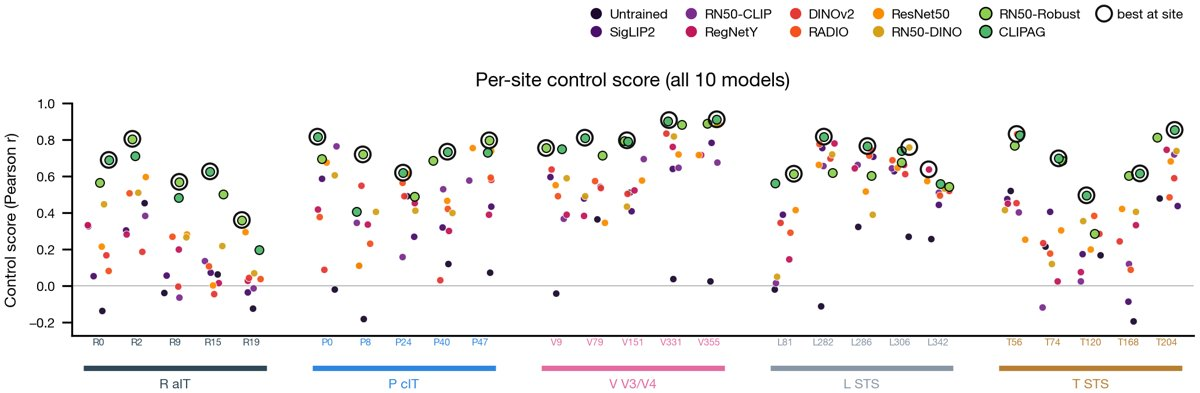

In [3]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# Show a downscaled JPEG preview (the full-resolution PNG can be tens of MB); open the file for detail.
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))